# 1. Handle Outliers

This notebook detects and handles outliers in the null-handled dataset **before** applying SMOTE,
so that synthetic minority samples are generated from clean, realistic data points.

## Pipeline
1. Load the null-handled processed data
2. Identify numerical features to inspect
3. Visualise distributions & boxplots
4. Detect outliers using the **IQR (Interquartile Range)** method
5. Handle outliers using **IQR Capping (Winsorization)** — clip values to [Q1 − 1.5·IQR, Q3 + 1.5·IQR]
6. Verify before vs. after
7. Save the cleaned data to `dataset/processed/outliers_handled.csv`

> **Why IQR Capping instead of dropping?**  
> In fraud detection the dataset is already severely imbalanced (only ~1.5% fraud).  
> Dropping outlier rows risks losing genuine fraud signals. Capping preserves all rows
> while bounding extreme values to a reasonable range.

## 1. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print('Imports successful.')

Imports successful.


## 2. Load Processed Data

In [2]:
INPUT_PATH = 'C:/Users/2021ICTS28/Desktop/end-to-end-credit-card-fraud-detection-system/dataset/processed/credit_card_fraud_null_handled.csv'

df = pd.read_csv(INPUT_PATH)
print(f'Loaded: {{df.shape[0]:,}} rows x {{df.shape[1]}} columns')
df.head()

Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.4700,22,Electronics,0,0,66,3,40,0
1,2,541.8200,3,Travel,1,0,87,1,64,0
2,3,237.0100,17,Grocery,0,0,49,1,61,0
3,4,164.3300,4,Grocery,0,1,72,3,34,0
4,5,30.5300,15,Food,0,0,79,0,44,0


In [3]:
# Identify numerical features eligible for outlier treatment
# Exclude: transaction_id (ID), binary flags (0/1), and the target
BINARY_COLS  = ['foreign_transaction', 'location_mismatch', 'is_fraud']
ID_COLS      = ['transaction_id']
CAT_COLS     = ['merchant_category']

NUMERIC_COLS = [
    c for c in df.select_dtypes(include='number').columns
    if c not in BINARY_COLS + ID_COLS
]

print('Columns to inspect for outliers:', NUMERIC_COLS)

Columns to inspect for outliers: ['amount', 'transaction_hour', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']


## 3. Visualise Distributions & Boxplots (Before)

C:\Users\2021ICTS28\AppData\Local\Temp\ipykernel_10620\4254624182.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, i].boxplot(df[col], vert=True, patch_artist=True,
C:\Users\2021ICTS28\AppData\Local\Temp\ipykernel_10620\4254624182.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, i].boxplot(df[col], vert=True, patch_artist=True,
C:\Users\2021ICTS28\AppData\Local\Temp\ipykernel_10620\4254624182.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, i].boxplot(df[col], vert=True, patch_artist=True,
C:\Users\2021ICTS28\AppData\Local\Temp\ipykernel_10620\4254624182.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated i

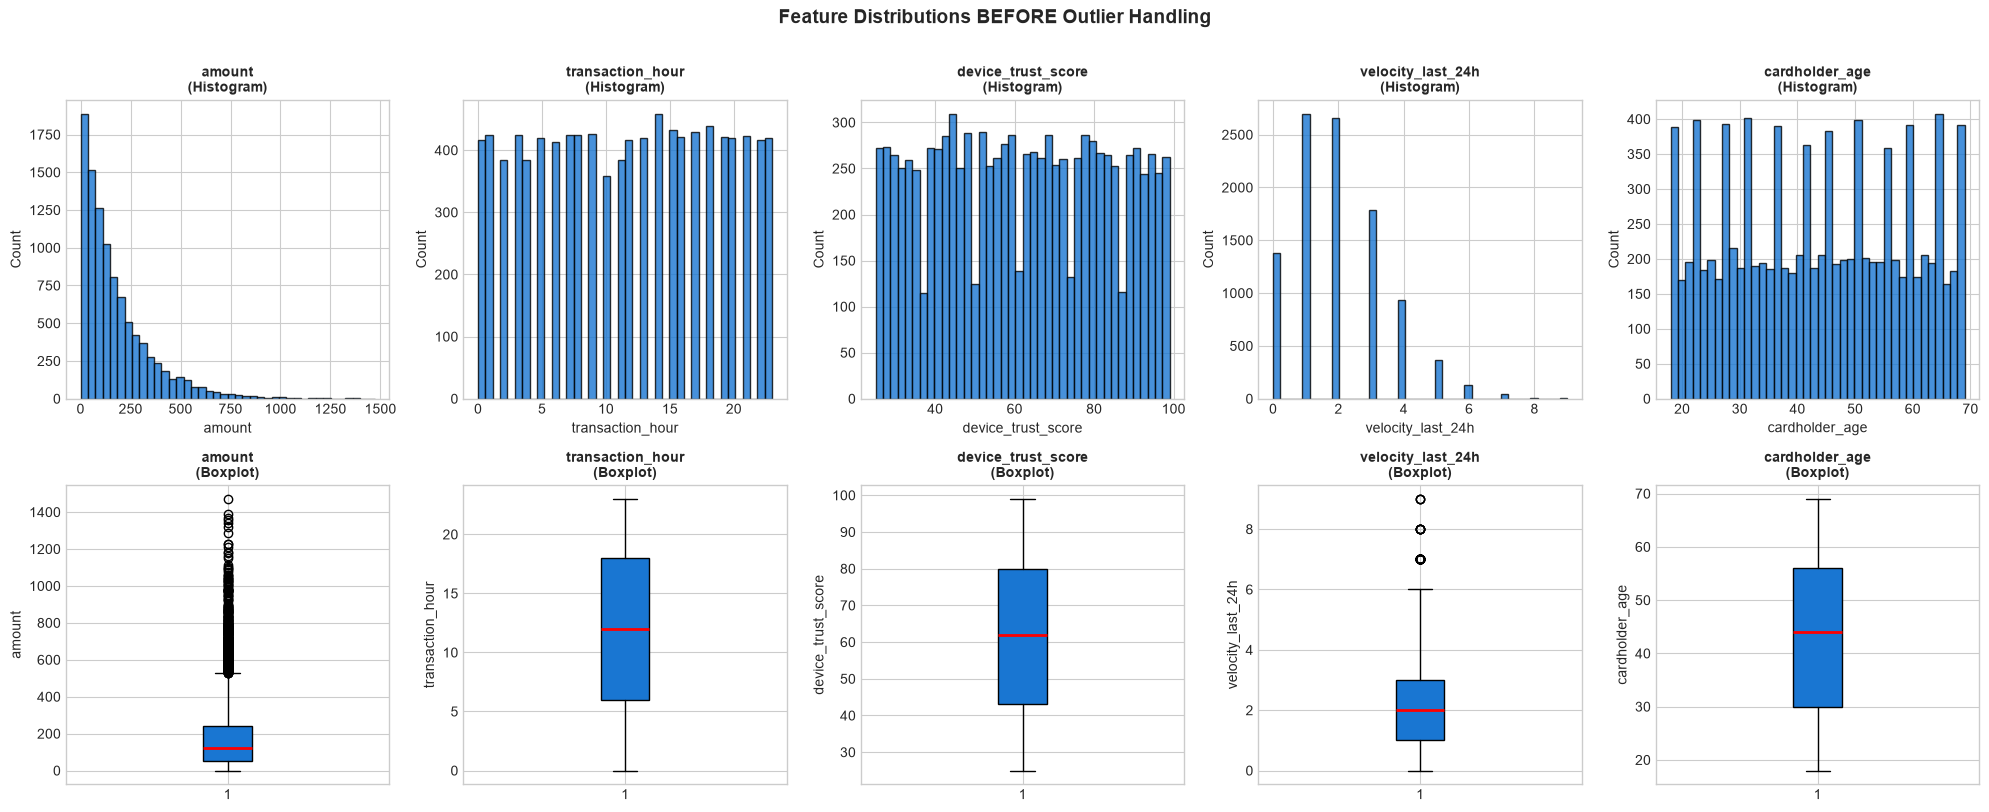

In [4]:
n_cols = len(NUMERIC_COLS)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))

for i, col in enumerate(NUMERIC_COLS):
    # Histogram
    axes[0, i].hist(df[col], bins=40, color='#1976D2', edgecolor='black', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(Histogram)', fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')

    # Boxplot
    axes[1, i].boxplot(df[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#1976D2', color='black'),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col}\n(Boxplot)', fontsize=10, fontweight='bold')
    axes[1, i].set_ylabel(col)

plt.suptitle('Feature Distributions BEFORE Outlier Handling', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Detect Outliers — IQR Method

For each numerical column we compute:
- **Q1** = 25th percentile
- **Q3** = 75th percentile  
- **IQR** = Q3 − Q1
- **Lower fence** = Q1 − 1.5 × IQR
- **Upper fence** = Q3 + 1.5 × IQR

Any value outside `[Lower fence, Upper fence]` is flagged as an outlier.

In [5]:
def compute_iqr_bounds(series):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return Q1, Q3, IQR, lower, upper

outlier_report = []

for col in NUMERIC_COLS:
    Q1, Q3, IQR, lower, upper = compute_iqr_bounds(df[col])
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (n_outliers / len(df)) * 100
    outlier_report.append({
        'Column'       : col,
        'Min'          : df[col].min(),
        'Q1'           : Q1,
        'Median'       : df[col].median(),
        'Q3'           : Q3,
        'Max'          : df[col].max(),
        'IQR'          : IQR,
        'Lower Fence'  : lower,
        'Upper Fence'  : upper,
        'Outlier Count': n_outliers,
        'Outlier %'    : round(pct, 2)
    })

report_df = pd.DataFrame(outlier_report).set_index('Column')
print('=== IQR Outlier Report ===')
report_df

=== IQR Outlier Report ===


,Min,Q1,Median,Q3,Max,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier %
Column,,,,,,,,,,
amount,0.0000,50.9050,122.0950,242.4800,1471.0400,191.5750,-236.4575,529.8425,501,5.0100
transaction_hour,0.0000,6.0000,12.0000,18.0000,23.0000,12.0000,-12.0000,36.0000,0,0.0000
device_trust_score,25.0000,43.0000,62.0000,80.0000,99.0000,37.0000,-12.5000,135.5000,0,0.0000
velocity_last_24h,0.0000,1.0000,2.0000,3.0000,9.0000,2.0000,-2.0000,6.0000,51,0.5100
cardholder_age,18.0000,30.0000,44.0000,56.0000,69.0000,26.0000,-9.0000,95.0000,0,0.0000


In [6]:
# Highlight columns with outliers
flagged = report_df[report_df['Outlier Count'] > 0][['Outlier Count', 'Outlier %', 'Lower Fence', 'Upper Fence']]
print(f'Columns with outliers: {len(flagged)}')
print()
print(flagged.to_string())

Columns with outliers: 2

                   Outlier Count  Outlier %  Lower Fence  Upper Fence
Column                                                               
amount                       501     5.0100    -236.4575     529.8425
velocity_last_24h             51     0.5100      -2.0000       6.0000


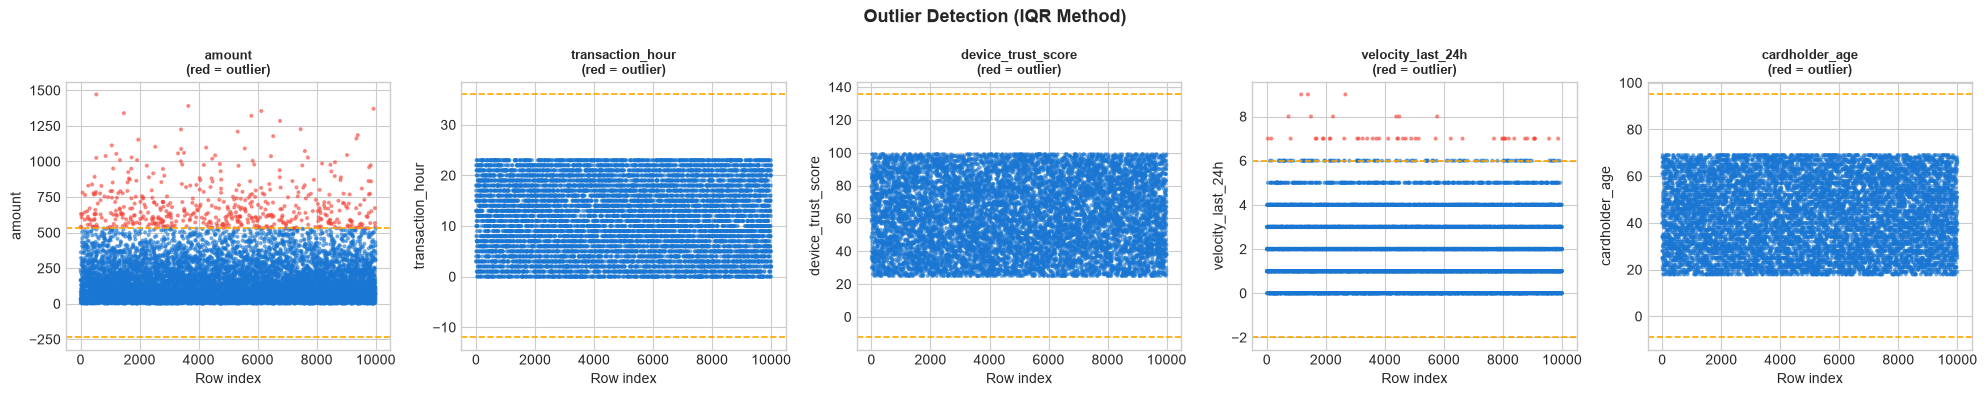

In [7]:
# Scatter plot highlighting outliers per column
fig, axes = plt.subplots(1, len(NUMERIC_COLS), figsize=(4 * len(NUMERIC_COLS), 4))

for i, col in enumerate(NUMERIC_COLS):
    _, _, _, lower, upper = compute_iqr_bounds(df[col])
    is_outlier = (df[col] < lower) | (df[col] > upper)

    axes[i].scatter(range(len(df)), df[col],
                    c=is_outlier.map({True: '#F44336', False: '#1976D2'}),
                    s=4, alpha=0.5)
    axes[i].axhline(upper, color='orange', linestyle='--', linewidth=1.2, label='Upper fence')
    axes[i].axhline(lower, color='orange', linestyle='--', linewidth=1.2, label='Lower fence')
    axes[i].set_title(f'{col}\n(red = outlier)', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Row index')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection (IQR Method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Handle Outliers — IQR Capping (Winsorization)

We **clip** each value to its column's `[Lower Fence, Upper Fence]`:
- Values **below** the lower fence → replaced with the lower fence value
- Values **above** the upper fence → replaced with the upper fence value

All rows are preserved — only extreme values are bounded.

In [8]:
df_clean = df.copy()

capping_log = []
for col in NUMERIC_COLS:
    _, _, _, lower, upper = compute_iqr_bounds(df_clean[col])
    before_low  = (df_clean[col] < lower).sum()
    before_high = (df_clean[col] > upper).sum()

    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    capping_log.append({
        'Column'           : col,
        'Lower Fence'      : round(lower, 4),
        'Upper Fence'      : round(upper, 4),
        'Capped (low)'     : int(before_low),
        'Capped (high)'    : int(before_high),
        'Total Capped'     : int(before_low + before_high)
    })

cap_df = pd.DataFrame(capping_log).set_index('Column')
print('=== Capping Summary ===')
print(cap_df.to_string())
print(f'\nTotal values capped: {cap_df["Total Capped"].sum()}')

=== Capping Summary ===
                    Lower Fence  Upper Fence  Capped (low)  Capped (high)  Total Capped
Column                                                                                 
amount                -236.4575     529.8425             0            501           501
transaction_hour       -12.0000      36.0000             0              0             0
device_trust_score     -12.5000     135.5000             0              0             0
velocity_last_24h       -2.0000       6.0000             0             51            51
cardholder_age          -9.0000      95.0000             0              0             0

Total values capped: 552


## 6. Verify — Before vs After

In [9]:
# Confirm no remaining outliers
remaining = []
for col in NUMERIC_COLS:
    _, _, _, lower, upper = compute_iqr_bounds(df[col])  # bounds from original
    n = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    remaining.append({'Column': col, 'Remaining Outliers': n})

rem_df = pd.DataFrame(remaining).set_index('Column')
print(rem_df)
assert rem_df['Remaining Outliers'].sum() == 0, 'Outliers still present!'
print('\nAll outliers have been handled.')

                    Remaining Outliers
Column                                
amount                               0
transaction_hour                     0
device_trust_score                   0
velocity_last_24h                    0
cardholder_age                       0

All outliers have been handled.


C:\Users\2021ICTS28\AppData\Local\Temp\ipykernel_4368\2255083462.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, i].boxplot(df[col], **bp_kwargs,
C:\Users\2021ICTS28\AppData\Local\Temp\ipykernel_4368\2255083462.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, i].boxplot(df_clean[col], **bp_kwargs,
C:\Users\2021ICTS28\AppData\Local\Temp\ipykernel_4368\2255083462.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, i].boxplot(df[col], **bp_kwargs,
C:\Users\2021ICTS28\AppData\Local\Temp\ipykernel_4368\2255083462.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use 

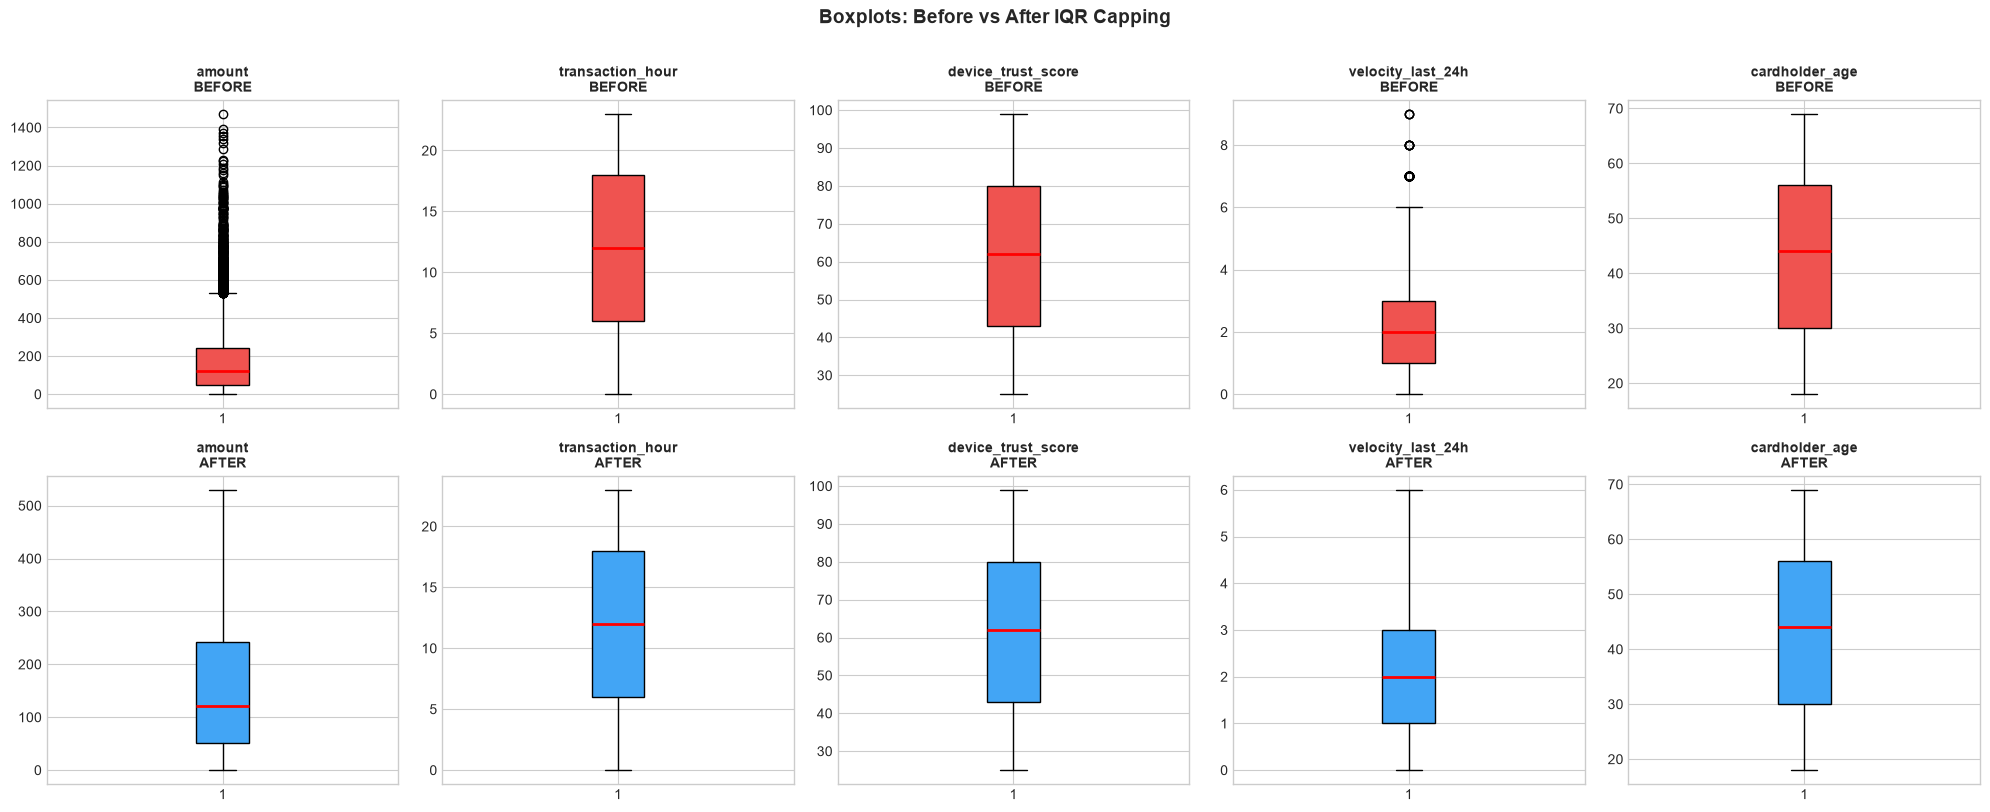

In [11]:
# Side-by-side boxplots: Before vs After
n_cols = len(NUMERIC_COLS)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))

for i, col in enumerate(NUMERIC_COLS):
    bp_kwargs = dict(vert=True, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))

    axes[0, i].boxplot(df[col], **bp_kwargs,
                       boxprops=dict(facecolor='#EF5350', color='black'))
    axes[0, i].set_title(f'{col}\nBEFORE', fontsize=10, fontweight='bold')

    axes[1, i].boxplot(df_clean[col], **bp_kwargs,
                       boxprops=dict(facecolor='#42A5F5', color='black'))
    axes[1, i].set_title(f'{col}\nAFTER', fontsize=10, fontweight='bold')

plt.suptitle('Boxplots: Before vs After IQR Capping', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# Statistical comparison
compare = pd.DataFrame({
    'mean_before' : df[NUMERIC_COLS].mean().round(4),
    'mean_after'  : df_clean[NUMERIC_COLS].mean().round(4),
    'std_before'  : df[NUMERIC_COLS].std().round(4),
    'std_after'   : df_clean[NUMERIC_COLS].std().round(4),
    'max_before'  : df[NUMERIC_COLS].max().round(4),
    'max_after'   : df_clean[NUMERIC_COLS].max().round(4),
    'min_before'  : df[NUMERIC_COLS].min().round(4),
    'min_after'   : df_clean[NUMERIC_COLS].min().round(4),
})
print('=== Statistical Comparison ===')
compare

=== Statistical Comparison ===


,mean_before,mean_after,std_before,std_after,max_before,max_after,min_before,min_after
amount,175.9498,167.5416,175.3928,148.1256,1471.0400,529.8425,0.0000,0.0000
transaction_hour,11.5933,11.5933,6.9227,6.9227,23.0000,23.0000,0.0000,0.0000
device_trust_score,61.7989,61.7989,21.4871,21.4871,99.0000,99.0000,25.0000,25.0000
velocity_last_24h,2.0089,2.0026,1.4326,1.4116,9.0000,6.0000,0.0000,0.0000
cardholder_age,43.4687,43.4687,14.9791,14.9791,69.0000,69.0000,18.0000,18.0000


In [11]:
print(f'Original shape : {df.shape}')
print(f'Cleaned shape  : {df_clean.shape}   (rows preserved — only values capped)')
print(f'\nClass distribution (unchanged):')
print(df_clean['is_fraud'].value_counts())
df_clean.head()

Original shape : (10000, 10)
Cleaned shape  : (10000, 10)   (rows preserved — only values capped)

Class distribution (unchanged):
is_fraud
0    9849
1     151
Name: count, dtype: int64


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.4700,22,Electronics,0,0,66,3,40,0
1,2,529.8425,3,Travel,1,0,87,1,64,0
2,3,237.0100,17,Grocery,0,0,49,1,61,0
3,4,164.3300,4,Grocery,0,1,72,3,34,0
4,5,30.5300,15,Food,0,0,79,0,44,0


## 7. Save Outlier-Handled Data

In [12]:
OUTPUT_DIR  = 'C:/Users/2021ICTS28/Desktop/end-to-end-credit-card-fraud-detection-system/dataset/processed'
OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'credit_card_fraud_outliers_handled.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)
df_clean.to_csv(OUTPUT_PATH, index=False)

file_size_kb = os.path.getsize(OUTPUT_PATH) / 1024
print(f'Saved to   : {OUTPUT_PATH}')
print(f'File size  : {file_size_kb:.1f} KB')
print(f'Shape      : {df_clean.shape}')

# Sanity check
df_check = pd.read_csv(OUTPUT_PATH)
assert df_check.shape == df_clean.shape, 'Shape mismatch!'
assert df_check.isnull().sum().sum() == 0, 'Null values found!'
print('\nSanity check passed.')

Saved to   : C:/Users/2021ICTS28/Desktop/end-to-end-credit-card-fraud-detection-system/dataset/processed\credit_card_fraud_outliers_handled.csv
File size  : 362.8 KB
Shape      : (10000, 10)

Sanity check passed.
